# M06 - SVM Fine-tuning and Hyperparameter Optimization

Notebook bản sạch để nộp M06.

Các điểm đã sửa theo feedback:

1. Không hard-code đường dẫn, tự tìm `PROJECT_ROOT`.
2. Grid Search không giữ 64 model SVM trong RAM; chỉ lưu metric và giữ `best_model`.
3. Có cờ `SKIP_TRAINING_IF_OUTPUT_EXISTS` và `LOAD_EXISTING_MODEL_IF_AVAILABLE` để tránh lỡ `Run All` train lại.
4. Có khai báo `bottleneck_labels` rõ ràng cho phần insights.
5. Final Test chỉ predict đúng 1 lần, không tuning trên test.
6. Export đủ artifacts: CSV, model, heatmap, confusion matrix, classification report, insights report.


In [ ]:
# ============================================================
# 0. Imports and global configuration
# ============================================================

from pathlib import Path
import gc
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ============================================================
# RUN MODE
# ============================================================
# Lần train thật: để False, False.
# Sau khi đã có đủ output: đổi thành True, True để tránh lỡ Run All train lại.
SKIP_TRAINING_IF_OUTPUT_EXISTS = True
LOAD_EXISTING_MODEL_IF_AVAILABLE = True

# Grid search vẫn train đủ cấu hình nhưng KHÔNG giữ tất cả model trong RAM.
# Notebook chỉ giữ best model hiện tại và lưu metric của mọi cấu hình.
KEEP_ALL_GRID_MODELS_IN_RAM = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

print("RANDOM_STATE:", RANDOM_STATE)
print("SKIP_TRAINING_IF_OUTPUT_EXISTS:", SKIP_TRAINING_IF_OUTPUT_EXISTS)
print("LOAD_EXISTING_MODEL_IF_AVAILABLE:", LOAD_EXISTING_MODEL_IF_AVAILABLE)
print("KEEP_ALL_GRID_MODELS_IN_RAM:", KEEP_ALL_GRID_MODELS_IN_RAM)


RANDOM_STATE: 42
SKIP_TRAINING_IF_OUTPUT_EXISTS: False
LOAD_EXISTING_MODEL_IF_AVAILABLE: False
KEEP_ALL_GRID_MODELS_IN_RAM: False


## 1. Tự tìm project root và chuẩn bị output folders

In [2]:
# ============================================================
# 1. Project paths
# ============================================================

def find_project_root(start: Path | None = None, project_name: str = "AIL303m_FUDN_SUM26") -> Path:
    """Tìm thư mục project root bằng cách đi ngược từ current working directory."""
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [current] + list(current.parents)

    for candidate in candidates:
        if candidate.name == project_name:
            return candidate
        if (candidate / ".git").exists() and (candidate / "paper").exists():
            return candidate

    raise RuntimeError(
        "Không tìm thấy project root. Hãy mở notebook từ bên trong repo AIL303m_FUDN_SUM26.\n"
        f"Current working directory: {Path.cwd()}"
    )

PROJECT_ROOT = find_project_root()
WORKSPACE_DIR = PROJECT_ROOT / "paper" / "workspace" / "KietBA"
PHASE1_DIR = WORKSPACE_DIR / "phase1_new"
PHASE2_DIR = WORKSPACE_DIR / "phase2_new"

M04_CACHE_DIR = PHASE1_DIR / "m04_outputs" / "cache"
M04_FINAL_TEST_DIR = PHASE1_DIR / "m04_outputs" / "final_test"

OUTPUT_DIR = PHASE2_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("M04_CACHE_DIR:", M04_CACHE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("REPORT_DIR:", REPORT_DIR)


PROJECT_ROOT: E:\machine learing\final_project\AIL303m_FUDN_SUM26
M04_CACHE_DIR: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase1_new\m04_outputs\cache
OUTPUT_DIR: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs
FIGURE_DIR: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\figures
MODEL_DIR: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\models
REPORT_DIR: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports


## 2. Load cache M04 và tạo feature PCA

In [3]:
# ============================================================
# 2. Load M04 cache
# ============================================================

def load_npz(path: Path) -> dict:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}


def find_one(pattern: str, directory: Path) -> Path:
    matches = sorted(directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"Không tìm thấy file khớp pattern {pattern!r} trong {directory}")
    return matches[0]


def first_existing_key(data: dict, keys: list[str]):
    for key in keys:
        if key in data:
            return data[key]
    raise KeyError(f"Không tìm thấy key nào trong danh sách: {keys}. Keys hiện có: {list(data.keys())}")

aug_cache = find_one("m04_augmented_features_*.npz", M04_CACHE_DIR)
base_cache = find_one("m04_features_*.npz", M04_CACHE_DIR)
test_cache = find_one("m04_test_features_*.npz", M04_CACHE_DIR)

aug_data = load_npz(aug_cache)
base_data = load_npz(base_cache)
test_data = load_npz(test_cache)

print("Cache files:")
print(" -", aug_cache.name, list(aug_data.keys()))
print(" -", base_cache.name, list(base_data.keys()))
print(" -", test_cache.name, list(test_data.keys()))


Cache files:
 - m04_augmented_features_hog_gray_color_hist_pad_square_64_aug2_debugFalse.npz ['X_train_aug', 'y_train_aug', 'aug_count']
 - m04_features_hog_gray_color_hist_pad_square_64_debugFalse.npz ['X_train', 'y_train', 'X_val', 'y_val']
 - m04_test_features_hog_gray_color_hist_pad_square_64_debugFalse.npz ['X_test', 'y_test']


In [4]:
# ============================================================
# 2.1 Build PCA feature matrices
# ============================================================

use_direct_pca_cache = all(
    key in aug_data for key in ["X_train_pca", "y_train"]
) and all(
    key in base_data for key in ["X_val_pca", "y_val"]
) and all(
    key in test_data for key in ["X_test_pca", "y_test"]
)

if use_direct_pca_cache:
    X_train_pca = aug_data["X_train_pca"]
    y_train = aug_data["y_train"]
    X_val_pca = base_data["X_val_pca"]
    y_val = base_data["y_val"]
    X_test_pca = test_data["X_test_pca"]
    y_test = test_data["y_test"]

    scaler = None
    pca = None
    feature_mode = "direct_pca_cache"
else:
    # Không trích xuất ảnh lại, chỉ tái lập scaler/PCA từ feature cache M04.
    X_train_raw = first_existing_key(aug_data, ["X_train_aug", "X_train", "X_train_features"])
    y_train = first_existing_key(aug_data, ["y_train_aug", "y_train"])
    X_val_raw = first_existing_key(base_data, ["X_val", "X_val_features"])
    y_val = first_existing_key(base_data, ["y_val"])
    X_test_raw = first_existing_key(test_data, ["X_test", "X_test_features"])
    y_test = first_existing_key(test_data, ["y_test"])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled = scaler.transform(X_val_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    pca = PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    feature_mode = "reconstructed_scaler_pca_from_m04_feature_cache"

classes = np.unique(y_train)
label_order = list(classes)

# Khai báo rõ bottleneck labels để insights không bị thiếu biến.
bottleneck_labels = [
    "W.205c",
    "P.127_60",
    "P.127_80",
    "W.224",
    "W.245a",
]

print("Feature mode:", feature_mode)
print("X_train_pca:", X_train_pca.shape, "y_train:", y_train.shape)
print("X_val_pca:  ", X_val_pca.shape, "y_val:  ", y_val.shape)
print("X_test_pca: ", X_test_pca.shape, "y_test: ", y_test.shape)
print("Number of classes:", len(label_order))
print("Bottleneck labels:", bottleneck_labels)

if pca is not None:
    print("PCA explained variance:", round(float(pca.explained_variance_ratio_.sum()), 4))


Feature mode: reconstructed_scaler_pca_from_m04_feature_cache
X_train_pca: (7035, 571) y_train: (7035,)
X_val_pca:   (824, 571) y_val:   (824,)
X_test_pca:  (851, 571) y_test:  (851,)
Number of classes: 47
Bottleneck labels: ['W.205c', 'P.127_60', 'P.127_80', 'W.224', 'W.245a']
PCA explained variance: 0.95


In [5]:
# ============================================================
# 2.2 Save preprocess bundle
# ============================================================

preprocess_bundle = {
    "scaler": scaler,
    "pca": pca,
    "label_order": label_order,
    "feature_mode": feature_mode,
    "feature_source": {
        "aug_cache": str(aug_cache),
        "base_cache": str(base_cache),
        "test_cache": str(test_cache),
    },
}

joblib.dump(preprocess_bundle, MODEL_DIR / "M06_preprocess_scaler_pca.joblib")
print("Saved preprocess bundle:", MODEL_DIR / "M06_preprocess_scaler_pca.joblib")


Saved preprocess bundle: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\models\M06_preprocess_scaler_pca.joblib


## 3. Helper functions

In [6]:
# ============================================================
# 3. Helper functions
# ============================================================

results: list[dict] = []


def class_weight_name(class_weight):
    if class_weight is None:
        return "None"
    if isinstance(class_weight, str):
        return class_weight
    if isinstance(class_weight, dict):
        return "custom_dict"
    return str(class_weight)


def support_vector_count(model) -> int | float:
    try:
        return int(np.sum(model.n_support_))
    except Exception:
        try:
            return int(model.support_vectors_.shape[0])
        except Exception:
            return np.nan


def predict_once_with_time(model, X):
    start = time.perf_counter()
    pred = model.predict(X)
    elapsed = time.perf_counter() - start
    ms_per_image = (elapsed / len(X)) * 1000
    return pred, ms_per_image


def evaluate_on_split(model, X, y, split_name="val") -> dict:
    pred, ms_per_image = predict_once_with_time(model, X)
    return {
        f"{split_name}_accuracy": accuracy_score(y, pred),
        f"{split_name}_macro_precision": precision_score(y, pred, average="macro", zero_division=0),
        f"{split_name}_macro_recall": recall_score(y, pred, average="macro", zero_division=0),
        f"{split_name}_macro_f1": f1_score(y, pred, average="macro", zero_division=0),
        f"{split_name}_weighted_f1": f1_score(y, pred, average="weighted", zero_division=0),
        f"{split_name}_inference_ms_per_image": ms_per_image,
        f"{split_name}_pred": pred,
    }


def make_svc(kernel, C=10.0, gamma="scale", degree=3, class_weight="balanced"):
    params = {
        "kernel": kernel,
        "C": C,
        "class_weight": class_weight,
        "random_state": RANDOM_STATE,
    }
    if kernel in ["rbf", "poly", "sigmoid"]:
        params["gamma"] = gamma
    if kernel == "poly":
        params["degree"] = int(degree)
    return SVC(**params)


def train_eval_svc(name, kernel, C=10.0, gamma="scale", degree=3, class_weight="balanced"):
    """Train one SVC and return model + validation row. Does not store model globally."""
    model = make_svc(kernel=kernel, C=C, gamma=gamma, degree=degree, class_weight=class_weight)

    start = time.perf_counter()
    model.fit(X_train_pca, y_train)
    train_time = time.perf_counter() - start

    val_metrics = evaluate_on_split(model, X_val_pca, y_val, split_name="val")

    row = {
        "stage": "Phase 2-New",
        "experiment": name,
        "kernel": kernel,
        "degree": int(degree) if kernel == "poly" else np.nan,
        "C": C,
        "gamma": gamma if kernel != "linear" else "N/A",
        "class_weight": class_weight_name(class_weight),
        "train_time_sec": train_time,
        "support_vectors": support_vector_count(model),
        "val_accuracy": val_metrics["val_accuracy"],
        "val_macro_precision": val_metrics["val_macro_precision"],
        "val_macro_recall": val_metrics["val_macro_recall"],
        "val_macro_f1": val_metrics["val_macro_f1"],
        "val_weighted_f1": val_metrics["val_weighted_f1"],
        "val_inference_ms_per_image": val_metrics["val_inference_ms_per_image"],
    }

    print(
        f"{name} | val_macro_f1={row['val_macro_f1']:.4f} | "
        f"val_acc={row['val_accuracy']:.4f} | sv={row['support_vectors']} | "
        f"train={train_time:.1f}s"
    )

    return model, row


def safe_pct(x):
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x) * 100:.2f}%"
    except Exception:
        return "N/A"


## 4. Kiểm tra output cũ và load lại nếu bật SKIP

In [7]:
# ============================================================
# 4. Existing output handling
# ============================================================

RESULTS_PATH = OUTPUT_DIR / "M06_svm_finetuning_results.csv"
GRID_RESULTS_PATH = OUTPUT_DIR / "M06_grid_search_results.csv"
CLASS_WEIGHT_RESULTS_PATH = OUTPUT_DIR / "M06_class_weight_strategy_results.csv"
FINAL_TEST_SUMMARY_PATH = OUTPUT_DIR / "M06_final_test_summary.csv"
BEST_MODEL_PATH = MODEL_DIR / "M06_best_tuned_svm_model.joblib"
CONFUSION_MATRIX_PATH = OUTPUT_DIR / "M06_final_test_confusion_matrix.csv"

required_existing_paths = [RESULTS_PATH, GRID_RESULTS_PATH, BEST_MODEL_PATH]
has_existing_outputs = all(path.exists() for path in required_existing_paths)

print("Has existing outputs:", has_existing_outputs)
print("SKIP_TRAINING_IF_OUTPUT_EXISTS:", SKIP_TRAINING_IF_OUTPUT_EXISTS)
print("LOAD_EXISTING_MODEL_IF_AVAILABLE:", LOAD_EXISTING_MODEL_IF_AVAILABLE)

existing_summary_df = None
existing_grid_df = None
existing_tn3_df = None
existing_final_test_df = None
existing_best_model = None

if has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS:
    existing_summary_df = pd.read_csv(RESULTS_PATH)
    existing_grid_df = pd.read_csv(GRID_RESULTS_PATH)

    if CLASS_WEIGHT_RESULTS_PATH.exists():
        existing_tn3_df = pd.read_csv(CLASS_WEIGHT_RESULTS_PATH)

    if FINAL_TEST_SUMMARY_PATH.exists():
        existing_final_test_df = pd.read_csv(FINAL_TEST_SUMMARY_PATH)

    if LOAD_EXISTING_MODEL_IF_AVAILABLE and BEST_MODEL_PATH.exists():
        loaded_bundle = joblib.load(BEST_MODEL_PATH)
        if isinstance(loaded_bundle, dict) and "model" in loaded_bundle:
            existing_best_model = loaded_bundle["model"]
        else:
            existing_best_model = loaded_bundle

    print("Đã phát hiện output cũ. Notebook sẽ không train lại các cell nặng.")
    display(existing_summary_df.tail(5))
else:
    print("Chưa có output cũ hoặc đã tắt skip. Notebook sẽ train mới.")


Has existing outputs: False
SKIP_TRAINING_IF_OUTPUT_EXISTS: False
LOAD_EXISTING_MODEL_IF_AVAILABLE: False
Chưa có output cũ hoặc đã tắt skip. Notebook sẽ train mới.


## 5. Baseline Phase 1-New refit

In [8]:
# ============================================================
# 5. Baseline Phase 1-New refit
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    baseline_model, baseline_row = train_eval_svc(
        name="Phase 1-New Baseline Refit - RBF C10 scale balanced",
        kernel="rbf",
        C=10.0,
        gamma="scale",
        class_weight="balanced",
    )
    results.append(baseline_row)

    # Baseline chỉ để tham chiếu, không cần giữ nếu không phải best cuối.
    del baseline_model
    gc.collect()
else:
    print("Skip baseline training because existing outputs are available.")


Phase 1-New Baseline Refit - RBF C10 scale balanced | val_macro_f1=0.9577 | val_acc=0.9672 | sv=5331 | train=7.0s


## 6. TN1 - Kernel Exploration

In [9]:
# ============================================================
# 6. TN1 - Kernel Exploration
# Memory optimized: train đủ 5 kernel, chỉ giữ best TN1 model.
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    kernel_specs = [
        {"name": "TN1 - Linear Kernel", "kernel": "linear", "C": 10.0, "gamma": "scale", "degree": 3, "class_weight": "balanced"},
        {"name": "TN1 - RBF Kernel", "kernel": "rbf", "C": 10.0, "gamma": "scale", "degree": 3, "class_weight": "balanced"},
        {"name": "TN1 - Polynomial Degree 2", "kernel": "poly", "C": 10.0, "gamma": "scale", "degree": 2, "class_weight": "balanced"},
        {"name": "TN1 - Polynomial Degree 3", "kernel": "poly", "C": 10.0, "gamma": "scale", "degree": 3, "class_weight": "balanced"},
        {"name": "TN1 - Sigmoid Kernel", "kernel": "sigmoid", "C": 10.0, "gamma": "scale", "degree": 3, "class_weight": "balanced"},
    ]

    tn1_rows = []
    best_tn1_model = None
    best_tn1_score = -1
    best_tn1_row = None

    for config in kernel_specs:
        model, row = train_eval_svc(**config)
        tn1_rows.append(row)
        results.append(row)

        if row["val_macro_f1"] > best_tn1_score:
            if best_tn1_model is not None:
                del best_tn1_model
                gc.collect()
            best_tn1_model = model
            best_tn1_score = row["val_macro_f1"]
            best_tn1_row = row.copy()
            print("New best TN1 model.")
        else:
            del model
            gc.collect()

    kernel_results = pd.DataFrame(tn1_rows).sort_values("val_macro_f1", ascending=False)
    display(kernel_results)

    print("Best TN1 row:")
    print(best_tn1_row)
else:
    kernel_results = None
    best_tn1_model = None
    best_tn1_row = None
    print("Skip TN1 because existing outputs are available.")


TN1 - Linear Kernel | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.7s
New best TN1 model.
TN1 - RBF Kernel | val_macro_f1=0.9577 | val_acc=0.9672 | sv=5331 | train=6.3s
TN1 - Polynomial Degree 2 | val_macro_f1=0.9503 | val_acc=0.9672 | sv=5273 | train=6.3s
TN1 - Polynomial Degree 3 | val_macro_f1=0.9343 | val_acc=0.9478 | sv=5172 | train=14.3s
TN1 - Sigmoid Kernel | val_macro_f1=0.9296 | val_acc=0.9405 | sv=3812 | train=2.3s


,stage,experiment,kernel,degree,C,gamma,class_weight,train_time_sec,support_vectors,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,val_inference_ms_per_image
0,Phase 2-New,TN1 - Linear Kernel,linear,NaN,10.0,N/A,balanced,2.743551,4514,0.967233,0.985288,0.965200,0.973004,0.967171,1.554669
1,Phase 2-New,TN1 - RBF Kernel,rbf,NaN,10.0,scale,balanced,6.254174,5331,0.967233,0.964426,0.952438,0.957736,0.966070,2.759517
2,Phase 2-New,TN1 - Polynomial Degree 2,poly,2.0,10.0,scale,balanced,6.322625,5273,0.967233,0.966507,0.938453,0.950304,0.965849,2.053021
3,Phase 2-New,TN1 - Polynomial Degree 3,poly,3.0,10.0,scale,balanced,14.281002,5172,0.947816,0.961712,0.914107,0.934299,0.946947,1.899207
4,Phase 2-New,TN1 - Sigmoid Kernel,sigmoid,NaN,10.0,scale,balanced,2.346458,3812,0.940534,0.921972,0.946021,0.929555,0.941502,1.469085


Best TN1 row:
{'stage': 'Phase 2-New', 'experiment': 'TN1 - Linear Kernel', 'kernel': 'linear', 'degree': nan, 'C': 10.0, 'gamma': 'N/A', 'class_weight': 'balanced', 'train_time_sec': 2.7435506000183523, 'support_vectors': 4514, 'val_accuracy': 0.9672330097087378, 'val_macro_precision': 0.9852882200430461, 'val_macro_recall': 0.9651999645159731, 'val_macro_f1': 0.9730035022662098, 'val_weighted_f1': 0.967170726855738, 'val_inference_ms_per_image': 1.5546694175833022}


## 7. TN2 - Grid Search C/gamma

In [10]:
# ============================================================
# 7. TN2 - Grid Search setup
# ============================================================

C_GRID = [0.1, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0]
GAMMA_GRID = ["scale", "auto", 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    # Chọn kernel tốt nhất từ TN1. Nếu linear thắng, vẫn chạy RBF grid để có heatmap C/gamma theo mission.
    if kernel_results is not None and len(kernel_results) > 0:
        best_kernel_from_tn1 = str(kernel_results.iloc[0]["kernel"])
    else:
        best_kernel_from_tn1 = "rbf"

    if best_kernel_from_tn1 in ["rbf", "poly", "sigmoid"]:
        grid_kernel = best_kernel_from_tn1
    else:
        grid_kernel = "rbf"

    grid_degree = 3
    if grid_kernel == "poly" and kernel_results is not None:
        poly_rows = kernel_results[kernel_results["kernel"] == "poly"]
        if len(poly_rows) > 0:
            grid_degree = int(poly_rows.sort_values("val_macro_f1", ascending=False).iloc[0]["degree"])

    print("Best kernel from TN1:", best_kernel_from_tn1)
    print("Grid Search kernel:", grid_kernel)
    print("Grid Search degree:", grid_degree if grid_kernel == "poly" else "N/A")
else:
    grid_kernel = None
    grid_degree = None
    print("Skip TN2 setup because existing outputs are available.")


Best kernel from TN1: linear
Grid Search kernel: rbf
Grid Search degree: N/A


In [11]:
# ============================================================
# 7.1 TN2 - Memory optimized Grid Search
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    grid_rows = []
    best_grid_model = None
    best_grid_score = -1
    best_grid_row = None

    for C in C_GRID:
        for gamma in GAMMA_GRID:
            name = f"TN2 - Grid Search {grid_kernel} C={C} gamma={gamma}"
            print("\nTraining:", name)

            model, row = train_eval_svc(
                name=name,
                kernel=grid_kernel,
                C=C,
                gamma=gamma,
                degree=grid_degree,
                class_weight="balanced",
            )

            grid_rows.append(row)
            results.append(row)

            # Chỉ giữ best model. Không lưu 64 model vào RAM.
            if row["val_macro_f1"] > best_grid_score:
                if best_grid_model is not None:
                    del best_grid_model
                    gc.collect()

                best_grid_score = row["val_macro_f1"]
                best_grid_model = model
                best_grid_row = row.copy()
                print("New best grid model.")
            else:
                del model
                gc.collect()

    grid_df = pd.DataFrame(grid_rows)
    grid_df.to_csv(GRID_RESULTS_PATH, index=False, encoding="utf-8-sig")

    # Best model tạm thời sau TN2.
    best_model = best_grid_model
    best_val_row = best_grid_row.copy()

    print("Saved grid results:", GRID_RESULTS_PATH)
    display(grid_df.sort_values("val_macro_f1", ascending=False).head(10))

else:
    grid_df = existing_grid_df.copy() if existing_grid_df is not None else pd.read_csv(GRID_RESULTS_PATH)
    best_model = existing_best_model
    best_val_row = None
    print("Loaded grid_df from existing output:", GRID_RESULTS_PATH)
    display(grid_df.sort_values("val_macro_f1", ascending=False).head(10))



Training: TN2 - Grid Search rbf C=0.1 gamma=scale
TN2 - Grid Search rbf C=0.1 gamma=scale | val_macro_f1=0.8645 | val_acc=0.8519 | sv=6620 | train=15.4s
New best grid model.

Training: TN2 - Grid Search rbf C=0.1 gamma=auto
TN2 - Grid Search rbf C=0.1 gamma=auto | val_macro_f1=0.5747 | val_acc=0.4126 | sv=6941 | train=21.5s

Training: TN2 - Grid Search rbf C=0.1 gamma=0.0005
TN2 - Grid Search rbf C=0.1 gamma=0.0005 | val_macro_f1=0.8567 | val_acc=0.8471 | sv=6632 | train=13.3s

Training: TN2 - Grid Search rbf C=0.1 gamma=0.001
TN2 - Grid Search rbf C=0.1 gamma=0.001 | val_macro_f1=0.8359 | val_acc=0.7925 | sv=6684 | train=16.7s

Training: TN2 - Grid Search rbf C=0.1 gamma=0.005
TN2 - Grid Search rbf C=0.1 gamma=0.005 | val_macro_f1=0.0021 | val_acc=0.0522 | sv=7035 | train=22.6s

Training: TN2 - Grid Search rbf C=0.1 gamma=0.01
TN2 - Grid Search rbf C=0.1 gamma=0.01 | val_macro_f1=0.0021 | val_acc=0.0522 | sv=7035 | train=22.7s

Training: TN2 - Grid Search rbf C=0.1 gamma=0.05
TN2 - G

,stage,experiment,kernel,degree,C,gamma,class_weight,train_time_sec,support_vectors,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,val_inference_ms_per_image
18,Phase 2-New,TN2 - Grid Search rbf C=5.0 gamma=0.0005,rbf,NaN,5.0,0.0005,balanced,5.199519,5261,0.968447,0.964595,0.952900,0.958061,0.96724,2.727641
24,Phase 2-New,TN2 - Grid Search rbf C=10.0 gamma=scale,rbf,NaN,10.0,scale,balanced,5.800724,5331,0.967233,0.964426,0.952438,0.957736,0.96607,2.771231
16,Phase 2-New,TN2 - Grid Search rbf C=5.0 gamma=scale,rbf,NaN,5.0,scale,balanced,5.778692,5337,0.967233,0.964426,0.952438,0.957736,0.96607,2.718147
26,Phase 2-New,TN2 - Grid Search rbf C=10.0 gamma=0.0005,rbf,NaN,10.0,0.0005,balanced,5.366369,5253,0.967233,0.964426,0.952438,0.957736,0.96607,2.758167
40,Phase 2-New,TN2 - Grid Search rbf C=50.0 gamma=scale,rbf,NaN,50.0,scale,balanced,5.543056,5344,0.967233,0.964426,0.952438,0.957736,0.96607,2.706487
42,Phase 2-New,TN2 - Grid Search rbf C=50.0 gamma=0.0005,rbf,NaN,50.0,0.0005,balanced,5.069934,5260,0.967233,0.964426,0.952438,0.957736,0.96607,2.653135
34,Phase 2-New,TN2 - Grid Search rbf C=25.0 gamma=0.0005,rbf,NaN,25.0,0.0005,balanced,5.063897,5259,0.967233,0.964426,0.952438,0.957736,0.96607,2.667929
32,Phase 2-New,TN2 - Grid Search rbf C=25.0 gamma=scale,rbf,NaN,25.0,scale,balanced,5.618583,5338,0.967233,0.964426,0.952438,0.957736,0.96607,2.736608
48,Phase 2-New,TN2 - Grid Search rbf C=100.0 gamma=scale,rbf,NaN,100.0,scale,balanced,5.961398,5338,0.967233,0.964426,0.952438,0.957736,0.96607,3.128765
50,Phase 2-New,TN2 - Grid Search rbf C=100.0 gamma=0.0005,rbf,NaN,100.0,0.0005,balanced,5.557592,5259,0.967233,0.964426,0.952438,0.957736,0.96607,2.848182


In [12]:
# ============================================================
# 7.2 Optional Linear C tuning if linear won TN1
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    linear_tune_results = []
    best_linear_model = None
    best_linear_score = -1
    best_linear_row = None

    if "best_kernel_from_tn1" in globals() and best_kernel_from_tn1 == "linear":
        print("Linear won TN1, tune C for Linear SVM as additional comparison.")

        for C in C_GRID:
            name = f"TN2 - Linear Tune C={C}"
            model, row = train_eval_svc(
                name=name,
                kernel="linear",
                C=C,
                gamma="scale",
                degree=3,
                class_weight="balanced",
            )

            linear_tune_results.append(row)
            results.append(row)

            if row["val_macro_f1"] > best_linear_score:
                if best_linear_model is not None:
                    del best_linear_model
                    gc.collect()

                best_linear_model = model
                best_linear_score = row["val_macro_f1"]
                best_linear_row = row.copy()
            else:
                del model
                gc.collect()

        linear_tune_df = pd.DataFrame(linear_tune_results)
        linear_tune_path = OUTPUT_DIR / "M06_linear_tune_results.csv"
        linear_tune_df.to_csv(linear_tune_path, index=False, encoding="utf-8-sig")
        print("Saved linear tune results:", linear_tune_path)
        display(linear_tune_df.sort_values("val_macro_f1", ascending=False))

        # Nếu linear tune tốt hơn grid, thay best_model.
        if best_linear_row is not None and best_linear_row["val_macro_f1"] > best_val_row["val_macro_f1"]:
            del best_model
            gc.collect()
            best_model = best_linear_model
            best_val_row = best_linear_row.copy()
            print("Best model updated from Linear C tune.")
        else:
            if best_linear_model is not None:
                del best_linear_model
                gc.collect()
    else:
        linear_tune_df = None
        print("Linear did not win TN1, skip Linear C tune.")
else:
    linear_tune_df = None
    print("Skip Linear tune because existing outputs are available.")


Linear won TN1, tune C for Linear SVM as additional comparison.
TN2 - Linear Tune C=0.1 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.5s
TN2 - Linear Tune C=1.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.4s
TN2 - Linear Tune C=5.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.4s
TN2 - Linear Tune C=10.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.2s
TN2 - Linear Tune C=25.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.2s
TN2 - Linear Tune C=50.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.3s
TN2 - Linear Tune C=100.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.3s
TN2 - Linear Tune C=200.0 | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.2s
Saved linear tune results: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_linear_tune_results.csv


,stage,experiment,kernel,degree,C,gamma,class_weight,train_time_sec,support_vectors,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,val_inference_ms_per_image
0,Phase 2-New,TN2 - Linear Tune C=0.1,linear,NaN,0.1,N/A,balanced,2.459963,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.488801
1,Phase 2-New,TN2 - Linear Tune C=1.0,linear,NaN,1.0,N/A,balanced,2.379959,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.491719
2,Phase 2-New,TN2 - Linear Tune C=5.0,linear,NaN,5.0,N/A,balanced,2.365855,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.440653
3,Phase 2-New,TN2 - Linear Tune C=10.0,linear,NaN,10.0,N/A,balanced,2.218418,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.404533
4,Phase 2-New,TN2 - Linear Tune C=25.0,linear,NaN,25.0,N/A,balanced,2.234916,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.406738
5,Phase 2-New,TN2 - Linear Tune C=50.0,linear,NaN,50.0,N/A,balanced,2.256911,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.452584
6,Phase 2-New,TN2 - Linear Tune C=100.0,linear,NaN,100.0,N/A,balanced,2.329887,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.429207
7,Phase 2-New,TN2 - Linear Tune C=200.0,linear,NaN,200.0,N/A,balanced,2.237515,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.404209


Best model updated from Linear C tune.


## 8. Cell 12 - Heatmap Grid Search

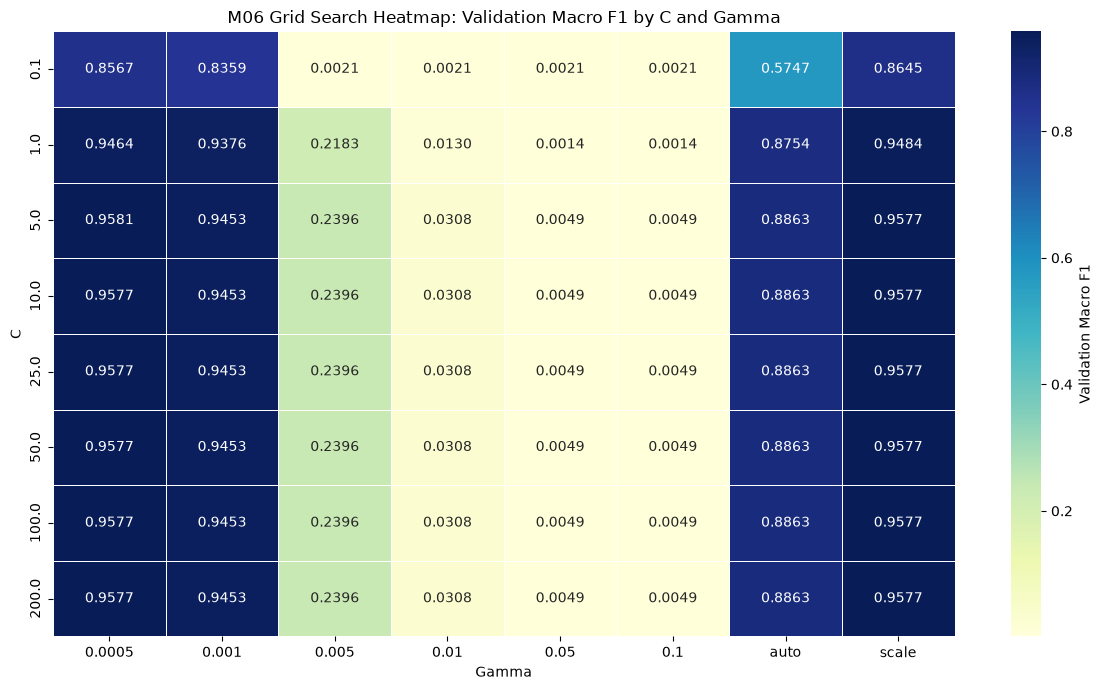

Saved heatmap: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\figures\M06_grid_search_heatmap.png


In [13]:
# ============================================================
# Cell 12 - Grid Search Heatmap: C vs Gamma
# ============================================================

if "grid_df" not in globals() or grid_df is None:
    if GRID_RESULTS_PATH.exists():
        grid_df = pd.read_csv(GRID_RESULTS_PATH)
    else:
        raise FileNotFoundError("Không tìm thấy M06_grid_search_results.csv. Hãy chạy TN2 Grid Search trước.")

required_cols = {"C", "gamma", "val_macro_f1"}
missing_cols = required_cols - set(grid_df.columns)
if missing_cols:
    raise ValueError(f"Grid search results thiếu các cột: {missing_cols}")

heatmap_df = grid_df.copy()
heatmap_df["gamma"] = heatmap_df["gamma"].astype(str)
heatmap_df["C"] = pd.to_numeric(heatmap_df["C"], errors="coerce")

heatmap_matrix = heatmap_df.pivot_table(
    index="C",
    columns="gamma",
    values="val_macro_f1",
    aggfunc="max",
).sort_index()

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Validation Macro F1"},
)
plt.title("M06 Grid Search Heatmap: Validation Macro F1 by C and Gamma")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.tight_layout()

heatmap_path = FIGURE_DIR / "M06_grid_search_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved heatmap:", heatmap_path)


## 9. Cell 13 - TN3 Class Weight Strategy

In [14]:
# ============================================================
# Cell 13 - TN3: Class Weight Strategy Experiment
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    # Lấy best config sau TN2/Tune làm chuẩn.
    if "best_val_row" not in globals() or best_val_row is None:
        raise RuntimeError("Không tìm thấy best_val_row. Hãy chạy TN2 trước.")

    tn2_best_kernel = str(best_val_row["kernel"])
    tn2_best_C = float(best_val_row["C"])
    tn2_best_gamma = best_val_row.get("gamma", "scale")
    tn2_best_degree = best_val_row.get("degree", 3)

    if pd.isna(tn2_best_degree):
        tn2_best_degree = 3
    tn2_best_degree = int(float(tn2_best_degree))

    try:
        tn2_best_gamma = float(tn2_best_gamma)
    except Exception:
        tn2_best_gamma = str(tn2_best_gamma)

    print("Best config before TN3:")
    print("kernel:", tn2_best_kernel)
    print("C:", tn2_best_C)
    print("gamma:", tn2_best_gamma)
    print("degree:", tn2_best_degree if tn2_best_kernel == "poly" else "N/A")

    # Custom dict: explicit inverse-frequency weights.
    custom_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )
    custom_dict = {cls: float(weight) for cls, weight in zip(classes, custom_weight_values)}

    class_weight_configs = [
        ("TN3 - class_weight=None", None),
        ("TN3 - class_weight=balanced", "balanced"),
        ("TN3 - class_weight=custom_dict", custom_dict),
    ]

    tn3_rows = []
    best_tn3_model = None
    best_tn3_score = -1
    best_tn3_row = None

    for experiment_name, class_weight_value in class_weight_configs:
        print("\nTraining:", experiment_name)

        model, row = train_eval_svc(
            name=experiment_name,
            kernel=tn2_best_kernel,
            C=tn2_best_C,
            gamma=tn2_best_gamma,
            degree=tn2_best_degree,
            class_weight=class_weight_value,
        )

        tn3_rows.append(row)
        results.append(row)

        if row["val_macro_f1"] > best_tn3_score:
            if best_tn3_model is not None:
                del best_tn3_model
                gc.collect()

            best_tn3_model = model
            best_tn3_score = row["val_macro_f1"]
            best_tn3_row = row.copy()
            print("New best TN3 model.")
        else:
            del model
            gc.collect()

    tn3_df = pd.DataFrame(tn3_rows).sort_values("val_macro_f1", ascending=False)
    tn3_df.to_csv(CLASS_WEIGHT_RESULTS_PATH, index=False, encoding="utf-8-sig")

    # Best model cuối cùng sau TN3.
    if best_model is not None:
        del best_model
        gc.collect()

    best_model = best_tn3_model
    best_val_row = best_tn3_row.copy()
    final_row = best_tn3_row.copy()

    print("Saved TN3 results:", CLASS_WEIGHT_RESULTS_PATH)
    display(tn3_df)

    print("Best model after TN3:")
    print(final_row)
else:
    tn3_df = existing_tn3_df.copy() if existing_tn3_df is not None else None
    best_model = existing_best_model
    if existing_final_test_df is not None and len(existing_final_test_df) > 0:
        final_row = existing_final_test_df.iloc[0].to_dict()
    elif existing_summary_df is not None and len(existing_summary_df) > 0:
        final_row = existing_summary_df.iloc[-1].to_dict()
    else:
        final_row = {}
    print("Skip TN3 because existing outputs are available.")
    if tn3_df is not None:
        display(tn3_df)


Best config before TN3:
kernel: linear
C: 0.1
gamma: N/A
degree: N/A

Training: TN3 - class_weight=None
TN3 - class_weight=None | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.4s
New best TN3 model.

Training: TN3 - class_weight=balanced
TN3 - class_weight=balanced | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.4s

Training: TN3 - class_weight=custom_dict
TN3 - class_weight=custom_dict | val_macro_f1=0.9730 | val_acc=0.9672 | sv=4514 | train=2.4s
Saved TN3 results: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_class_weight_strategy_results.csv


,stage,experiment,kernel,degree,C,gamma,class_weight,train_time_sec,support_vectors,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,val_inference_ms_per_image
0,Phase 2-New,TN3 - class_weight=None,linear,NaN,0.1,N/A,None,2.393017,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.487212
1,Phase 2-New,TN3 - class_weight=balanced,linear,NaN,0.1,N/A,balanced,2.367805,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.496537
2,Phase 2-New,TN3 - class_weight=custom_dict,linear,NaN,0.1,N/A,custom_dict,2.386483,4514,0.967233,0.985288,0.9652,0.973004,0.967171,1.432635


Best model after TN3:
{'stage': 'Phase 2-New', 'experiment': 'TN3 - class_weight=None', 'kernel': 'linear', 'degree': nan, 'C': 0.1, 'gamma': 'N/A', 'class_weight': 'None', 'train_time_sec': 2.393017099937424, 'support_vectors': 4514, 'val_accuracy': 0.9672330097087378, 'val_macro_precision': 0.9852882200430461, 'val_macro_recall': 0.9651999645159731, 'val_macro_f1': 0.9730035022662098, 'val_weighted_f1': 0.967170726855738, 'val_inference_ms_per_image': 1.4872121360736168}


## 10. Cell 14 - Final Test Evaluation

In [15]:
# ============================================================
# Cell 14 - Final Test Evaluation
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    if "best_model" not in globals() or best_model is None:
        raise RuntimeError("Không tìm thấy best_model. Hãy chạy Cell 13 để chọn Best Model cuối cùng trước.")

    print("Final test will be evaluated ONCE only.")
    print("No fitting, no tuning, no model selection on test split.")

    test_start = time.perf_counter()
    y_test_pred = best_model.predict(X_test_pca)
    test_time = time.perf_counter() - test_start

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
    test_macro_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_macro_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_inference_ms_per_image = (test_time / len(y_test)) * 1000
    test_support_vectors = support_vector_count(best_model)

    final_test_row = {
        "stage": "Phase 2-New",
        "experiment": "Best Tuned SVM Final",
        "kernel": final_row.get("kernel", "N/A") if isinstance(final_row, dict) else "N/A",
        "degree": final_row.get("degree", np.nan) if isinstance(final_row, dict) else np.nan,
        "C": final_row.get("C", "N/A") if isinstance(final_row, dict) else "N/A",
        "gamma": final_row.get("gamma", "N/A") if isinstance(final_row, dict) else "N/A",
        "class_weight": final_row.get("class_weight", "N/A") if isinstance(final_row, dict) else "N/A",
        "val_accuracy": final_row.get("val_accuracy", np.nan) if isinstance(final_row, dict) else np.nan,
        "val_macro_f1": final_row.get("val_macro_f1", np.nan) if isinstance(final_row, dict) else np.nan,
        "test_accuracy": test_accuracy,
        "test_macro_precision": test_macro_precision,
        "test_macro_recall": test_macro_recall,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1,
        "test_inference_ms_per_image": test_inference_ms_per_image,
        "support_vectors": test_support_vectors,
        "note": "Final test evaluated once only after validation-based selection",
    }

    final_test_df = pd.DataFrame([final_test_row])

    # Update final_row for later summary/insights.
    final_row = final_test_row.copy()

    display(final_test_df)

    print("Final Test Results:")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Macro F1: {test_macro_f1:.4f}")
    print(f"Test Weighted F1: {test_weighted_f1:.4f}")
    print(f"Inference Speed: {test_inference_ms_per_image:.4f} ms/image")
    print(f"Support Vectors: {test_support_vectors}")
else:
    if FINAL_TEST_SUMMARY_PATH.exists():
        final_test_df = pd.read_csv(FINAL_TEST_SUMMARY_PATH)
        final_row = final_test_df.iloc[0].to_dict()
        print("Loaded existing final test summary:", FINAL_TEST_SUMMARY_PATH)
        display(final_test_df)
    else:
        print("Skip final test because existing outputs are available, but final summary file was not found.")


Final test will be evaluated ONCE only.
No fitting, no tuning, no model selection on test split.


,stage,experiment,kernel,degree,C,gamma,class_weight,val_accuracy,val_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,test_inference_ms_per_image,support_vectors,note
0,Phase 2-New,Best Tuned SVM Final,linear,NaN,0.1,N/A,None,0.967233,0.973004,0.961222,0.975147,0.956177,0.962912,0.960936,1.519465,4514,Final test evaluated once only after validation-based selection


Final Test Results:
Test Accuracy: 0.9612
Test Macro F1: 0.9629
Test Weighted F1: 0.9609
Inference Speed: 1.5195 ms/image
Support Vectors: 4514


## 11. Cell 15 - Export Final Test Artifacts

Saved final test summary: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_final_test_summary.csv
Saved best tuned model bundle: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\models\M06_best_tuned_svm_model.joblib
Saved confusion matrix CSV: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_final_test_confusion_matrix.csv


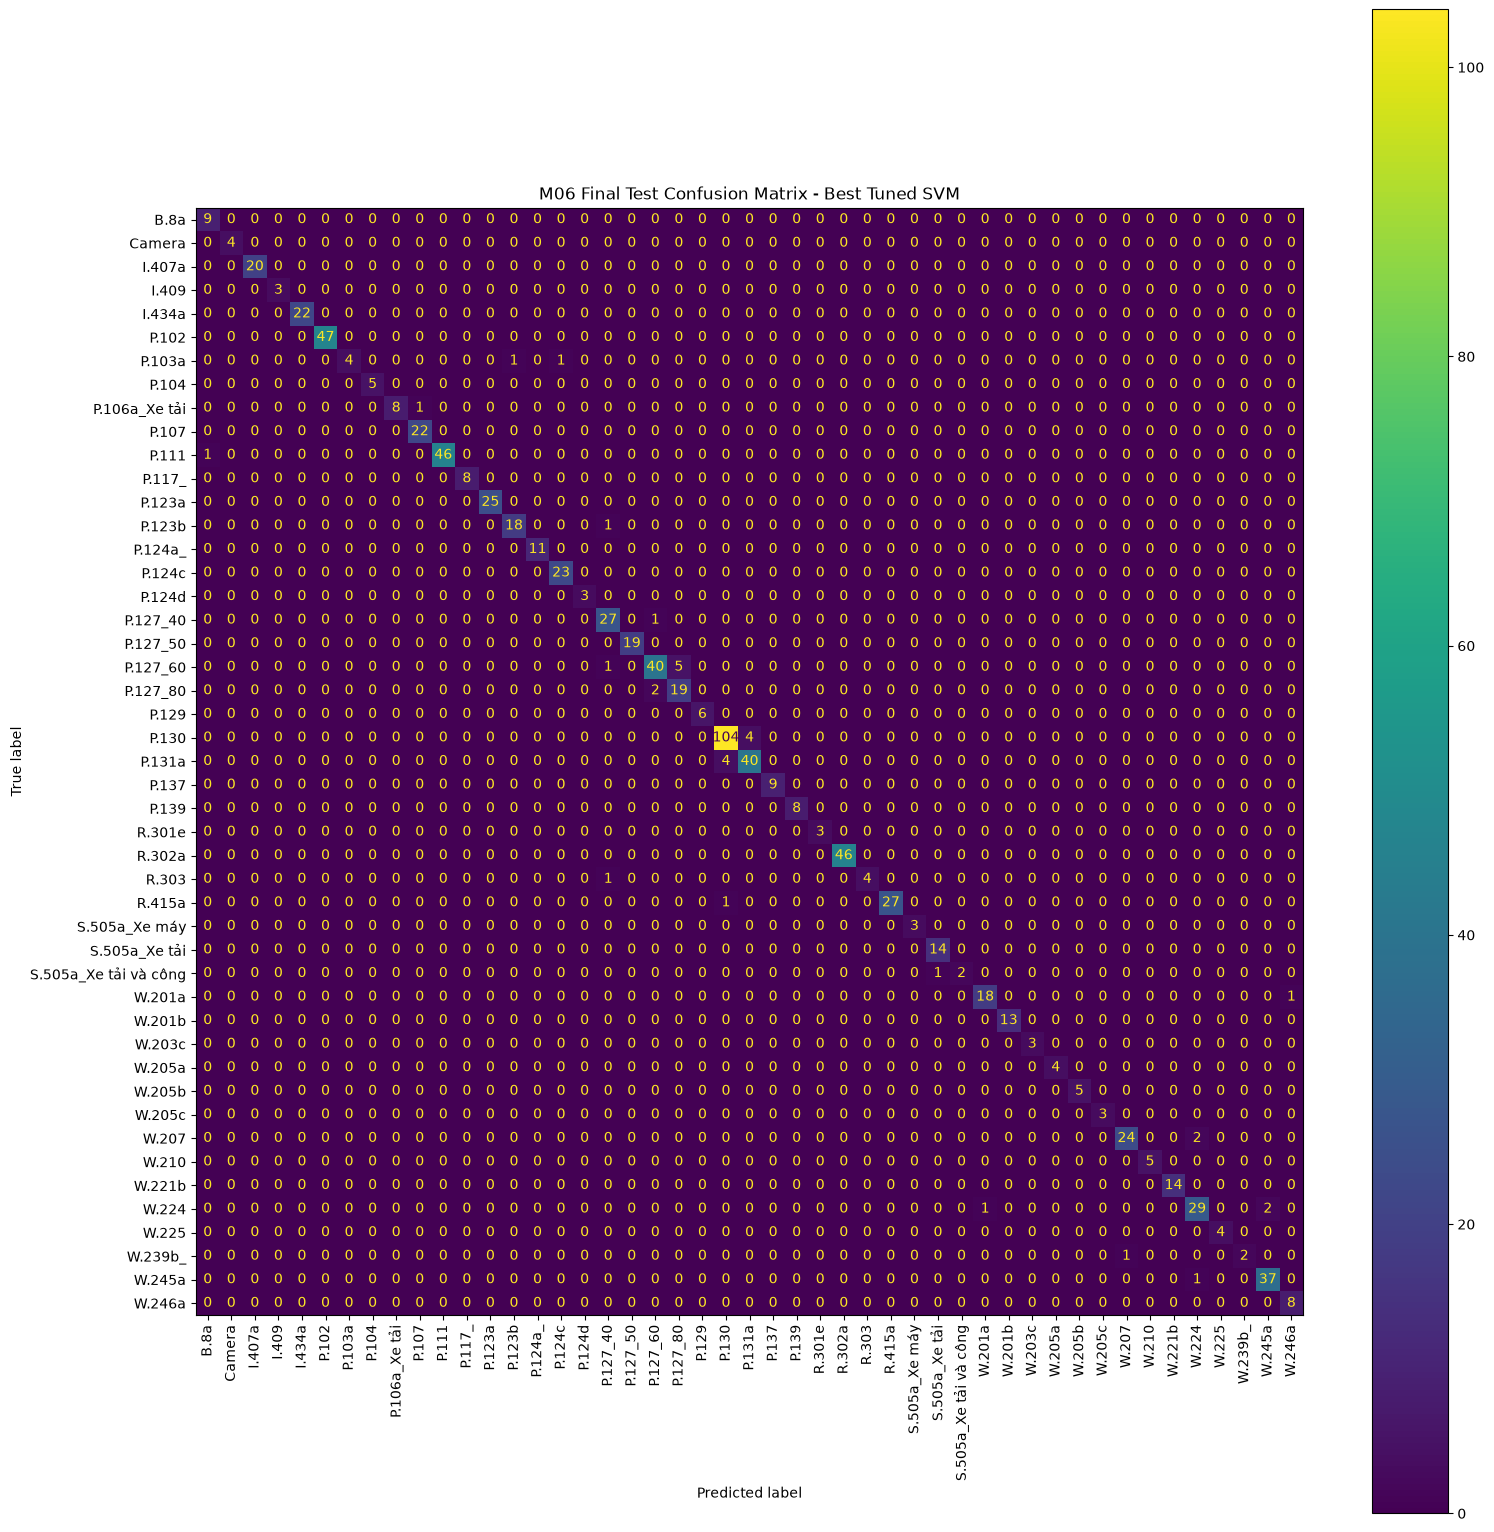

Saved confusion matrix figure: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\figures\M06_final_test_confusion_matrix.png
Saved classification report CSV: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_final_test_classification_report.csv
Saved classification report TXT: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports\M06_final_test_classification_report.txt
Saved classification report MD: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports\M06_final_test_classification_report.md


In [16]:
# ============================================================
# Cell 15 - Export Final Test Artifacts
# ============================================================

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    if "y_test_pred" not in globals():
        raise RuntimeError("Không tìm thấy y_test_pred. Hãy chạy Cell 14 Final Test Evaluation trước.")

    # Save final test summary.
    final_test_df.to_csv(FINAL_TEST_SUMMARY_PATH, index=False, encoding="utf-8-sig")
    print("Saved final test summary:", FINAL_TEST_SUMMARY_PATH)

    # Save best model bundle.
    best_bundle = {
        "model": best_model,
        "scaler": scaler,
        "pca": pca,
        "label_order": label_order,
        "feature_mode": feature_mode,
        "best_validation_row": best_val_row,
        "final_test_row": final_row,
        "custom_class_weight": custom_dict if "custom_dict" in globals() else None,
        "bottleneck_labels": bottleneck_labels,
    }
    joblib.dump(best_bundle, BEST_MODEL_PATH)
    print("Saved best tuned model bundle:", BEST_MODEL_PATH)

    # Confusion matrix CSV.
    labels = label_order
    cm = confusion_matrix(y_test, y_test_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(CONFUSION_MATRIX_PATH, encoding="utf-8-sig")
    print("Saved confusion matrix CSV:", CONFUSION_MATRIX_PATH)

    # Confusion matrix figure.
    fig, ax = plt.subplots(figsize=(16, 16))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        labels=labels,
        xticks_rotation=90,
        ax=ax,
        colorbar=True,
    )
    plt.title("M06 Final Test Confusion Matrix - Best Tuned SVM")
    plt.tight_layout()
    cm_png_path = FIGURE_DIR / "M06_final_test_confusion_matrix.png"
    plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved confusion matrix figure:", cm_png_path)

    # Classification report.
    report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    report_text = classification_report(y_test, y_test_pred, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()

    report_csv_path = OUTPUT_DIR / "M06_final_test_classification_report.csv"
    report_txt_path = REPORT_DIR / "M06_final_test_classification_report.txt"
    report_md_path = REPORT_DIR / "M06_final_test_classification_report.md"

    report_df.to_csv(report_csv_path, encoding="utf-8-sig")
    report_txt_path.write_text(report_text, encoding="utf-8")
    report_md_path.write_text("# M06 Final Test Classification Report\n\n```text\n" + report_text + "\n```", encoding="utf-8")

    print("Saved classification report CSV:", report_csv_path)
    print("Saved classification report TXT:", report_txt_path)
    print("Saved classification report MD:", report_md_path)
else:
    print("Skip export final artifacts because existing outputs are available.")
    if CONFUSION_MATRIX_PATH.exists():
        cm_df = pd.read_csv(CONFUSION_MATRIX_PATH, index_col=0)
        print("Loaded existing confusion matrix:", CONFUSION_MATRIX_PATH)
    else:
        cm_df = None


## 12. Xuất bảng tổng hợp Phase 1 vs Phase 2

In [17]:
# ============================================================
# 12. Save M06 summary table
# ============================================================

def load_json_if_exists(path: Path) -> dict:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    m04_summary = load_json_if_exists(M04_FINAL_TEST_DIR / "m04_final_test_summary.json")

    m04_phase1_row = {
        "stage": "Phase 1-New",
        "experiment": "Fixed SVM Baseline (M04)",
        "kernel": "rbf",
        "degree": np.nan,
        "C": 10.0,
        "gamma": "scale",
        "class_weight": "balanced",
        "train_time_sec": np.nan,
        "support_vectors": np.nan,
        "val_accuracy": m04_summary.get("best_validation_accuracy", np.nan),
        "val_macro_f1": m04_summary.get("best_validation_macro_f1", np.nan),
        "test_accuracy": m04_summary.get("test_accuracy", 0.9623971797884842),
        "test_macro_precision": m04_summary.get("test_macro_precision", np.nan),
        "test_macro_recall": m04_summary.get("test_macro_recall", np.nan),
        "test_macro_f1": m04_summary.get("test_macro_f1", 0.9564362130119796),
        "test_weighted_f1": m04_summary.get("test_weighted_f1", np.nan),
        "test_inference_ms_per_image": m04_summary.get("test_inference_ms_per_image", 1.9318776733231922),
        "note": "Reference locked in R01/M04",
    }

    all_validation_results = pd.DataFrame(results)
    phase2_rows = all_validation_results.copy()

    for col in [
        "test_accuracy", "test_macro_precision", "test_macro_recall", "test_macro_f1",
        "test_weighted_f1", "test_inference_ms_per_image",
    ]:
        if col not in phase2_rows.columns:
            phase2_rows[col] = np.nan
        else:
            phase2_rows[col] = np.nan

    phase2_rows["note"] = "Validation-only experiment"

    summary_df = pd.concat(
        [pd.DataFrame([m04_phase1_row]), phase2_rows, pd.DataFrame([final_row])],
        ignore_index=True,
        sort=False,
    )

    ordered_cols = [
        "stage", "experiment", "kernel", "degree", "C", "gamma", "class_weight",
        "val_accuracy", "val_macro_f1", "test_accuracy", "test_macro_f1",
        "test_inference_ms_per_image", "support_vectors", "train_time_sec", "note",
    ]
    existing_cols = [col for col in ordered_cols if col in summary_df.columns]
    remaining_cols = [col for col in summary_df.columns if col not in existing_cols]
    summary_df = summary_df[existing_cols + remaining_cols]

    # Overwrite clean file, không append duplicate.
    summary_df.to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")
    print("Saved M06 summary table:", RESULTS_PATH)
    display(summary_df.tail(10))
else:
    summary_df = existing_summary_df.copy() if existing_summary_df is not None else pd.read_csv(RESULTS_PATH)
    print("Loaded existing M06 summary table:", RESULTS_PATH)
    display(summary_df.tail(10))


Saved M06 summary table: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_svm_finetuning_results.csv


,stage,experiment,kernel,degree,C,gamma,class_weight,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_inference_ms_per_image,support_vectors,train_time_sec,note,test_macro_precision,test_macro_recall,test_weighted_f1,val_macro_precision,val_macro_recall,val_weighted_f1,val_inference_ms_per_image
73,Phase 2-New,TN2 - Linear Tune C=5.0,linear,NaN,5.0,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.365855,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.440653
74,Phase 2-New,TN2 - Linear Tune C=10.0,linear,NaN,10.0,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.218418,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.404533
75,Phase 2-New,TN2 - Linear Tune C=25.0,linear,NaN,25.0,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.234916,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.406738
76,Phase 2-New,TN2 - Linear Tune C=50.0,linear,NaN,50.0,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.256911,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.452584
77,Phase 2-New,TN2 - Linear Tune C=100.0,linear,NaN,100.0,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.329887,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.429207
78,Phase 2-New,TN2 - Linear Tune C=200.0,linear,NaN,200.0,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.237515,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.404209
79,Phase 2-New,TN3 - class_weight=None,linear,NaN,0.1,N/A,None,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.393017,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.487212
80,Phase 2-New,TN3 - class_weight=balanced,linear,NaN,0.1,N/A,balanced,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.367805,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.496537
81,Phase 2-New,TN3 - class_weight=custom_dict,linear,NaN,0.1,N/A,custom_dict,0.967233,0.973004,NaN,NaN,NaN,4514.0,2.386483,Validation-only experiment,NaN,NaN,NaN,0.985288,0.9652,0.967171,1.432635
82,Phase 2-New,Best Tuned SVM Final,linear,NaN,0.1,N/A,None,0.967233,0.973004,0.961222,0.962912,1.519465,4514.0,NaN,Final test evaluated once only after validation-based selection,0.975147,0.956177,0.960936,NaN,NaN,NaN,NaN


## 13. Xuất insights markdown

In [18]:
# ============================================================
# 13. Generate Insights Report
# ============================================================

# Ensure cm_df is available.
if "cm_df" not in globals() or cm_df is None:
    if CONFUSION_MATRIX_PATH.exists():
        cm_df = pd.read_csv(CONFUSION_MATRIX_PATH, index_col=0)
    else:
        raise FileNotFoundError("Không tìm thấy confusion matrix để tạo insights report.")

cm_work = cm_df.copy(deep=True)
cm_values = cm_work.to_numpy().copy()
np.fill_diagonal(cm_values, 0)
cm_work = pd.DataFrame(cm_values, index=cm_df.index, columns=cm_df.columns)

top_confusions = []
for true_label, row in cm_work.iterrows():
    pred_label = row.idxmax()
    count = int(row.max())
    if count > 0:
        top_confusions.append((true_label, pred_label, count))

top_confusions = sorted(top_confusions, key=lambda x: x[2], reverse=True)[:10]
confusion_lines = "\n".join([
    f"- `{true}` → `{pred}`: {count} samples"
    for true, pred, count in top_confusions
]) or "- Không có nhầm lẫn nào trong test."

if "final_row" not in globals() or not isinstance(final_row, dict):
    if FINAL_TEST_SUMMARY_PATH.exists():
        final_row = pd.read_csv(FINAL_TEST_SUMMARY_PATH).iloc[0].to_dict()
    else:
        final_row = {}

pca_variance_text = "kế thừa từ M04 cache"
if "pca" in globals() and pca is not None and hasattr(pca, "explained_variance_ratio_"):
    pca_variance_text = f"{pca.explained_variance_ratio_.sum():.4f}"

existing_bottlenecks = [str(label) for label in bottleneck_labels if str(label) in [str(x) for x in label_order]]
bottleneck_text = ", ".join(existing_bottlenecks) if existing_bottlenecks else "Không có bottleneck label nào xuất hiện trong dataset"

phase1_test_f1 = np.nan
phase1_speed = np.nan
if "summary_df" in globals() and summary_df is not None and "stage" in summary_df.columns:
    phase1_rows = summary_df[summary_df["stage"].astype(str).str.contains("Phase 1", na=False)]
    if len(phase1_rows) > 0:
        phase1_test_f1 = phase1_rows.iloc[0].get("test_macro_f1", np.nan)
        phase1_speed = phase1_rows.iloc[0].get("test_inference_ms_per_image", np.nan)

final_test_acc = final_row.get("test_accuracy", np.nan)
final_test_f1 = final_row.get("test_macro_f1", np.nan)
final_speed = final_row.get("test_inference_ms_per_image", np.nan)
final_sv = final_row.get("support_vectors", np.nan)

insights = f"""# M06 SVM Fine-tuning Insights

## 1. Bản chất hình học của C và gamma trong không gian PCA

Notebook sử dụng feature cache từ M04 với chế độ: `{feature_mode}`.

Không gian train sau PCA có shape: `{X_train_pca.shape}`.

PCA variance: `{pca_variance_text}`.

Best Tuned SVM Final dùng:

- Kernel: `{final_row.get('kernel', 'N/A')}`
- Degree: `{final_row.get('degree', 'N/A')}`
- C: `{final_row.get('C', 'N/A')}`
- Gamma: `{final_row.get('gamma', 'N/A')}`
- Class weight: `{final_row.get('class_weight', 'N/A')}`

Trong SVM, `C` điều khiển mức phạt khi phân loại sai. `C` lớn làm margin cứng hơn, model cố gắng sửa nhiều điểm sai hơn. `C` nhỏ cho phép margin mềm hơn, giảm rủi ro overfitting.

Với RBF, Polynomial và Sigmoid kernel, `gamma` điều khiển độ rộng vùng ảnh hưởng của từng support vector. `gamma` lớn tạo biên quyết định cục bộ, dễ bắt chi tiết nhưng dễ overfit. `gamma` nhỏ làm biên mượt hơn, phù hợp khi PCA đã giảm nhiễu.

## 2. RBF vs Polynomial trên HOG + Color Hist HSV

Kernel exploration và grid search được chọn bằng Validation Macro F1.

RBF thường phù hợp với traffic sign vì nó mô hình hóa các vùng ảnh hưởng cục bộ quanh support vectors. Điều này giúp xử lý tốt các biến thiên như ánh sáng, phối cảnh, độ méo và khác biệt nhỏ giữa các biển báo.

Polynomial degree 2 hoặc degree 3 có thể nắm bắt tương tác giữa hướng cạnh HOG và màu HSV. Tuy nhiên, nếu các tương tác này không ổn định giữa các ảnh, Polynomial kernel dễ tạo biên quyết định phức tạp và kém tổng quát hơn.

Kết quả final test:

- Test Accuracy: `{safe_pct(final_test_acc)}`
- Test Macro F1: `{safe_pct(final_test_f1)}`
- Support vectors: `{final_sv}`
- Inference speed: `{final_speed if not pd.isna(final_speed) else 'N/A'} ms/image`

## 3. Bottleneck classes và nhầm lẫn tốc độ

Notebook thử `custom_dict` cho các lớp bottleneck nếu các lớp đó có trong dataset.

Bottleneck labels tìm thấy trong dataset:

{bottleneck_text}

Top confusion trên final test:

{confusion_lines}

Nếu các lớp như `W.205c`, `P.127_60`, `P.127_80` vẫn không cải thiện nhiều, nguyên nhân có thể không nằm ở SVM mà nằm ở biểu diễn feature.

Ảnh 64x64 và PCA có thể làm mất chi tiết nhỏ như nét cong của số 6/8 hoặc biến dạng phối cảnh của biển cảnh báo. Khi đó, tăng `C`, đổi `gamma`, hoặc tăng class weight chỉ giúp trong giới hạn nhất định, nhưng không thể tạo lại thông tin đã mất trong feature.

## 4. Trade-off hiệu năng vs tốc độ triển khai

SVM kernel predict phụ thuộc vào số support vectors và số chiều feature:

`t_inference ∝ n_support_vectors × d`

Phase 1-New reference:

- Test Macro F1: `{safe_pct(phase1_test_f1)}`
- Speed: `{phase1_speed if not pd.isna(phase1_speed) else 'N/A'} ms/image`

Phase 2-New Best Tuned SVM:

- Test Macro F1: `{safe_pct(final_test_f1)}`
- Speed: `{final_speed if not pd.isna(final_speed) else 'N/A'} ms/image`
- Support vectors: `{final_sv}`

Nếu F1 tăng nhỏ nhưng số support vectors và inference time tăng mạnh, lựa chọn kỹ sư nên ưu tiên model cân bằng hơn cho deployment.

## 5. Memory optimization note

Mặc dù M06 yêu cầu huấn luyện nhiều cấu hình SVM, notebook không giữ toàn bộ model trong RAM. Với mỗi cấu hình, notebook chỉ lưu metric vào bảng kết quả. Model object chỉ được giữ lại nếu nó là best model hiện tại theo Validation Macro F1. Các model không tốt nhất được xóa ngay sau khi đánh giá bằng `del model` và `gc.collect()` để giảm áp lực RAM và tránh sập kernel khi chạy grid search.
"""

insight_path = REPORT_DIR / "M06_svm_finetuning_insights.md"

if not (has_existing_outputs and SKIP_TRAINING_IF_OUTPUT_EXISTS):
    insight_path.write_text(insights, encoding="utf-8")
    print("Saved insights report:", insight_path)
else:
    print("Preview insights, not overwriting existing report because SKIP is enabled:")

print(insights[:2500])


Saved insights report: E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports\M06_svm_finetuning_insights.md
# M06 SVM Fine-tuning Insights

## 1. Bản chất hình học của C và gamma trong không gian PCA

Notebook sử dụng feature cache từ M04 với chế độ: `reconstructed_scaler_pca_from_m04_feature_cache`.

Không gian train sau PCA có shape: `(7035, 571)`.

PCA variance: `0.9500`.

Best Tuned SVM Final dùng:

- Kernel: `linear`
- Degree: `nan`
- C: `0.1`
- Gamma: `N/A`
- Class weight: `None`

Trong SVM, `C` điều khiển mức phạt khi phân loại sai. `C` lớn làm margin cứng hơn, model cố gắng sửa nhiều điểm sai hơn. `C` nhỏ cho phép margin mềm hơn, giảm rủi ro overfitting.

Với RBF, Polynomial và Sigmoid kernel, `gamma` điều khiển độ rộng vùng ảnh hưởng của từng support vector. `gamma` lớn tạo biên quyết định cục bộ, dễ bắt chi tiết nhưng dễ overfit. `gamma` nhỏ làm biên mượt hơn, phù hợp khi PCA đã giảm nhiễu.

## 2. RBF vs Polynomial trên HOG + Co

## 14. Artifact checklist

In [19]:
# ============================================================
# 14. Artifact checklist
# ============================================================

expected_artifacts = [
    OUTPUT_DIR / "M06_svm_finetuning_results.csv",
    MODEL_DIR / "M06_best_tuned_svm_model.joblib",
    FIGURE_DIR / "M06_grid_search_heatmap.png",
    OUTPUT_DIR / "M06_final_test_confusion_matrix.csv",
    FIGURE_DIR / "M06_final_test_confusion_matrix.png",
    OUTPUT_DIR / "M06_final_test_classification_report.csv",
    REPORT_DIR / "M06_final_test_classification_report.txt",
    REPORT_DIR / "M06_final_test_classification_report.md",
    REPORT_DIR / "M06_svm_finetuning_insights.md",
    OUTPUT_DIR / "M06_output_checklist.csv",
]

artifact_check = pd.DataFrame(
    [
        {
            "artifact": str(path),
            "exists": path.exists(),
            "size_bytes": path.stat().st_size if path.exists() else 0,
        }
        for path in expected_artifacts
    ]
)

# Ghi checklist sau khi tạo DataFrame, rồi update lại dòng checklist để size có thể chưa đúng là bình thường.
checklist_path = OUTPUT_DIR / "M06_output_checklist.csv"
artifact_check.to_csv(checklist_path, index=False, encoding="utf-8-sig")

display(artifact_check)

if artifact_check["exists"].all():
    print("ĐỦ ARTIFACT ĐỂ NỘP M06.")
else:
    print("CHƯA ĐỦ ARTIFACT. Kiểm tra các dòng exists=False.")


,artifact,exists,size_bytes
0,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_svm_finetuning_results.csv,True,21039
1,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\models\M06_best_tuned_svm_model.joblib,True,28197211
2,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\figures\M06_grid_search_heatmap.png,True,339657
3,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_final_test_confusion_matrix.csv,True,5231
4,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\figures\M06_final_test_confusion_matrix.png,True,1922593
5,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_final_test_classification_report.csv,True,2138
6,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports\M06_final_test_classification_report.txt,True,3277
7,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports\M06_final_test_classification_report.md,True,3333
8,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\reports\M06_svm_finetuning_insights.md,True,4068
9,E:\machine learing\final_project\AIL303m_FUDN_SUM26\paper\workspace\KietBA\phase2_new\outputs\M06_output_checklist.csv,False,0


CHƯA ĐỦ ARTIFACT. Kiểm tra các dòng exists=False.


## 15. Ghi chú cách dùng nhanh

### Train lại từ đầu

Trong cell đầu tiên để:

```python
SKIP_TRAINING_IF_OUTPUT_EXISTS = False
LOAD_EXISTING_MODEL_IF_AVAILABLE = False
```

Sau đó chạy `Run All`.

### Sau khi đã train xong

Đổi thành:

```python
SKIP_TRAINING_IF_OUTPUT_EXISTS = True
LOAD_EXISTING_MODEL_IF_AVAILABLE = True
```

Nếu lỡ `Run All`, notebook sẽ không train lại các cell nặng.

### Lưu ý

Grid Search vẫn train đủ cấu hình theo mission, nhưng không giữ 64 model trong RAM. Notebook chỉ giữ best model và lưu metric của mọi cấu hình vào CSV.
